In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv')

In [3]:
df.head(2)

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355


In [5]:
x = df.iloc[:,:3]
y = df.iloc[:,-1]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# 1. Linear Relationship

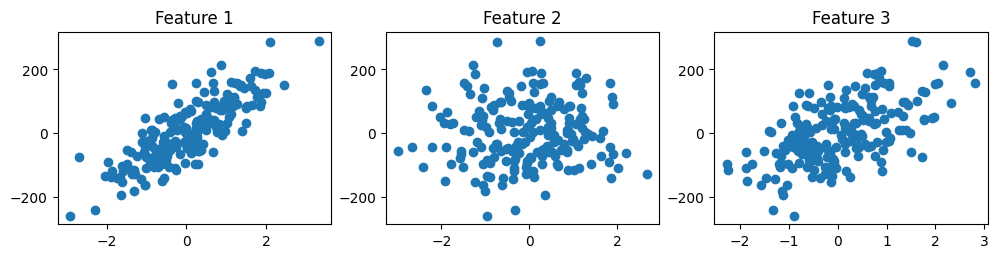

In [11]:
fig, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(12,2.5))

ax1.scatter(df['feature1'],df['target'])
ax1.set_title("Feature 1")
ax2.scatter(df['feature2'],df['target'])
ax2.set_title("Feature 2")
ax3.scatter(df['feature3'],df['target'])
ax3.set_title("Feature 3")

plt.show()

so we can clearly see that feature 1 vs target has a linear relationship
feature 2 vs target doesn't has linear relationship
feature 3 vs target  has slightly linear relationship

# 2. Multicollinearity

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = []
for i in range(x_train.shape[1]):
    vif.append(variance_inflation_factor(x_train,i))

In [ ]:
pd.DataFrame({'vif': vif},index=df.columns[0:3]).T

#the multicollinearity is not present in the dataset
#the multiollinearity must be below 5

,feature1,feature2,feature3
vif,1.00195,1.011273,1.011211


# 3. Normality of Residual

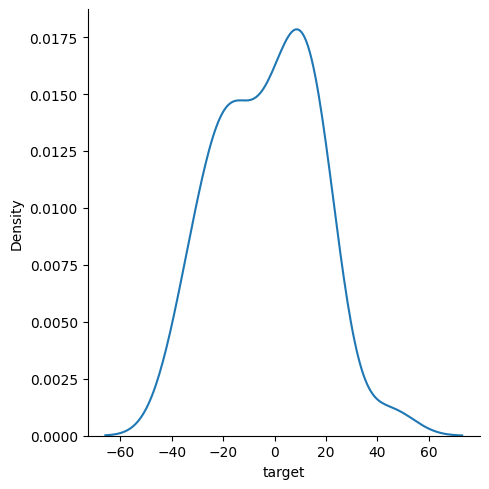

In [ ]:
residual = y_test - lr.predict(x_test)
sns.displot(residual,kind='kde')

#the residuals are normally distributed

# 4. Homoscedasticity

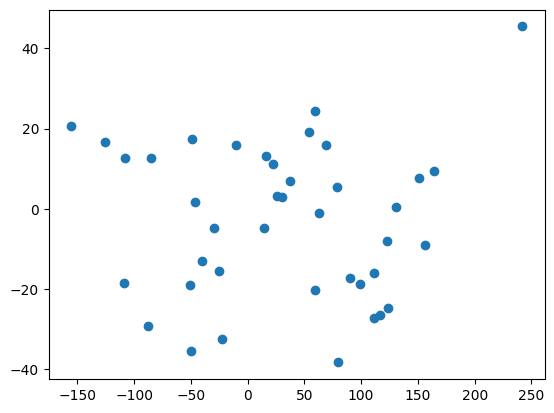

In [ ]:
plt.scatter(lr.predict(x_test),residual)
#the residuals are homoscedastic
#homo means same and scedastic means scatter

# 5. Autocorrelation of Residuals

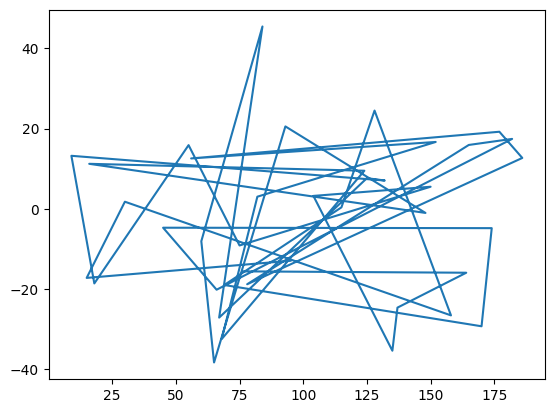

In [ ]:
plt.plot(residual)
#the residuals are independent of each other
#autocorrelation of residuals means that the residuals are not independent of each other